In [5]:
from unet_model import simple_unet_model
from keras.utils import normalize
import os
import cv2
from PIL import Image
import numpy as np 
from matplotlib import pyplot as plt

In [6]:
image_directory = 'Code/DS/train/images/'
mask_directory = 'Code/DS/train/masks/'

In [7]:
SIZE =256
image_dataset = []
mask_dataset=[]

In [8]:
images = os.listdir(image_directory)
images

['3.tif',
 '4.png',
 '1.png',
 '2.tif',
 '5.tif',
 '2.png',
 '3.png',
 '1.tif',
 '4.tif',
 '5.png']

In [9]:
for i , image_name in enumerate(images):
    if(image_name.split('.')[1] =='png'):
        image = cv2.imread(image_directory + image_name, 0)
        image = Image.fromarray(image)
        image = image.resize((SIZE, SIZE))
        image_dataset.append(np.array(image))

In [10]:
image_dataset

[array([[132, 125, 115, ..., 167, 177, 177],
        [108, 104, 104, ..., 169, 168, 182],
        [115, 121, 107, ..., 171, 177, 186],
        ...,
        [114, 111, 104, ..., 128, 151, 144],
        [107, 109, 107, ..., 130, 159, 151],
        [135, 139, 137, ..., 123, 133, 139]], shape=(256, 256), dtype=uint8),
 array([[115, 124, 131, ..., 166, 180, 187],
        [102, 108, 120, ..., 161, 178, 185],
        [ 98, 110, 122, ..., 150, 176, 189],
        ...,
        [ 99,  99,  98, ..., 114, 162, 156],
        [104, 115, 116, ..., 125, 161, 163],
        [134, 135, 140, ..., 117, 132, 146]], shape=(256, 256), dtype=uint8),
 array([[115, 119, 122, ..., 167, 179, 185],
        [103, 104, 112, ..., 162, 176, 192],
        [ 96, 115, 114, ..., 160, 179, 190],
        ...,
        [102, 100,  98, ..., 118, 159, 160],
        [110, 113, 115, ..., 128, 161, 164],
        [131, 143, 143, ..., 115, 133, 150]], shape=(256, 256), dtype=uint8),
 array([[129, 125, 115, ..., 168, 180, 182],
       

In [11]:
masks = os.listdir(mask_directory)
masks

['gt1.png',
 'gt5.png',
 'gt3.tif',
 'gt4.png',
 'gt2.png',
 'gt3.png',
 'gt4.tif',
 'gt2.tif',
 'gt5.tif',
 'gt1.tif']

In [12]:
for i , image_name in enumerate(masks):
    if(image_name.split('.')[1] =='png'):
        image = cv2.imread(mask_directory + image_name, 0)
        image = Image.fromarray(image)
        image = image.resize((SIZE, SIZE))
        mask_dataset.append(np.array(image))

In [13]:
mask_dataset

[array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(256, 256), dtype=uint8),
 array([[0, 0, 0, ..., 0

In [14]:
image_dataset = np.expand_dims(normalize(np.array(image_dataset), axis=1), 3)
mask_dataset = np.expand_dims((np.array(mask_dataset)), 3)/255.

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(image_dataset, 
                                                    mask_dataset, test_size=0.1, random_state=42)

In [16]:
IMG_HEIGHT= image_dataset.shape[1]
IMG_WIDTH = image_dataset.shape[2]
IMG_CHANNELS = image_dataset.shape[3]

In [17]:
def get_model():
    return simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [18]:
model = get_model()

I0000 00:00:1783101725.646445   14207 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3918 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]  

 Total params: 1,940,817 (7.40 MB)

 Trainable params: 1,940,817 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(X_train, y_train, batch_size=16, verbose=1, epochs=5, validation_data=(X_test, y_test), shuffle=False)

Epoch 1/5


2026-07-03 21:32:11.435545: I external/local_xla/xla/service/service.cc:163] XLA service 0x70c404002880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-03 21:32:11.435557: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 SUPER, Compute Capability 7.5
2026-07-03 21:32:11.591326: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-03 21:32:12.458770: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-07-03 21:32:14.382119: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[4,16,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[4,1,256,256]{3,2,1,0}, f32[16,1,3,3]{3,2,1,0}, f32[16]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.4396 - loss: 0.7040

I0000 00:00:1783101748.689971   17869 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-07-03 21:32:29.642261: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,128,32,32]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,64,32,32]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-07-03 21:32:29.704410: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,128,32,32]{3,2,1,0}, u8[0]{0}) cu

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step - accuracy: 0.4396 - loss: 0.7040 - val_accuracy: 0.7583 - val_loss: 0.5794
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7665 - loss: 0.5205 - val_accuracy: 0.9023 - val_loss: 0.4500
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8791 - loss: 0.9783 - val_accuracy: 0.9039 - val_loss: 0.4391
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8840 - loss: 0.3709 - val_accuracy: 0.9044 - val_loss: 0.5699
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8899 - loss: 0.5019 - val_accuracy: 0.9044 - val_loss: 0.5898


In [20]:
_, acc = model.evaluate(X_test, y_test)
acc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9044 - loss: 0.5898


0.9044342041015625

In [21]:
y_pred = model.predict(X_test)
y_pred_th = y_pred > 0.5
y_pred_th

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


array([[[[False],
         [False],
         [False],
         ...,
         [False],
         [False],
         [False]],

        [[False],
         [False],
         [False],
         ...,
         [False],
         [False],
         [False]],

        [[ True],
         [False],
         [False],
         ...,
         [False],
         [False],
         [False]],

        ...,

        [[False],
         [False],
         [False],
         ...,
         [False],
         [False],
         [False]],

        [[False],
         [False],
         [False],
         ...,
         [False],
         [False],
         [False]],

        [[False],
         [False],
         [False],
         ...,
         [False],
         [False],
         [ True]]]], shape=(1, 256, 256, 1))

In [22]:
intersection = np.logical_and(y_test, y_pred_th)
union = np.logical_or(y_test, y_pred_th)
mean_iou = np.sum(intersection)/np.sum(union)
mean_iou

np.float64(0.0)

In [23]:
import random 
import tensorflow as tf

def display(display_list):
    title = ['Input_image', 'True_mask', 'Predicted_mask']
    plt.figure(figsize=(15, 15))
    for i in range(len(display_list)):
        im = tf.keras.utils.array_to_img(display_list[i])
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(im, cmap='gray')
        plt.axis('off')
    plt.show()
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


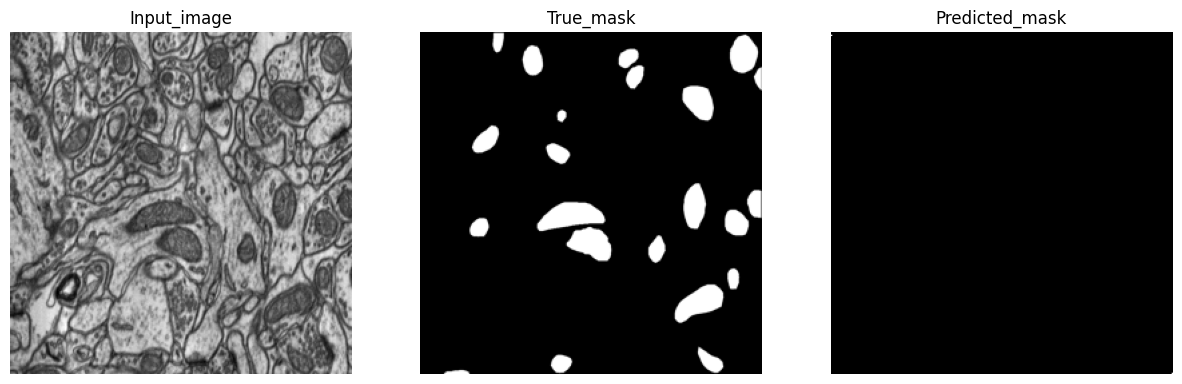

In [24]:
i = random.randint(0, len(X_train))
sample_image = X_train[i]
sample_mask = y_train[i]

prediction = model.predict(sample_image[tf.newaxis, ...])[0]
predicted_mask = (prediction > 0.5).astype(np.uint8)
display([sample_image, sample_mask, predicted_mask])
